In [ ]:
"https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv"

## Basic DataFrame

Consider the following Python dictionary data and Python list labels:

```
data = {'birds': ['Cranes', 'Cranes', 'plovers', 'spoonbills', 'spoonbills', 'Cranes', 'plovers', 'Cranes', 'spoonbills', 'spoonbills', 'Cranes'],
        'age': [3.5, 4, 1.5, np.nan, 6, 3, 5.5, np.nan, 8, 4, 3.5], 'visits': [2, 4, 3, 4, 3, 4, 2, 2, 3, 2, 2],
        'priority': ['yes', 'yes', 'no', np.nan, 'no', 'no', 'no', 'yes', 'no', 'no','yes']}
```
```
labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k']
```

###`Q-1:`
i. Create a DataFrame birds from the above dictionary data which has the index labels.
ii. Display basic information about the dataFrame.
iii. Show Alternate rows of the dataframe.

In [1]:
import numpy as np
import pandas as pd

In [16]:
data = {'birds': ['Cranes', 'Cranes', 'plovers', 'spoonbills', 'spoonbills', 'Cranes', 'plovers', 'Cranes', 'spoonbills', 'spoonbills', 'Cranes'],
        'age': [3.5, 4, 1.5, np.nan, 6, 3, 5.5, np.nan, 8, 4, 3.5], 'visits': [2, 4, 3, 4, 3, 4, 2, 2, 3, 2, 2],
        'priority': ['yes', 'yes', 'no', np.nan, 'no', 'no', 'no', 'yes', 'no', 'no','yes']}
labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k']
# i. Create a DataFrame birds from the above dictionary data which has the index labels.
birds_dataframe=pd.DataFrame(data, index=labels)
# ii. Display basic information about the dataFrame.
print(birds_dataframe)
birds_dataframe.info()
# iii. Show Alternate rows of the dataframe.
birds_dataframe.iloc[[1,3,5,7]] # by index
birds_dataframe.loc["a":"f"] # by label
birds_dataframe.iloc[::2]

        birds  age  visits priority
a      Cranes  3.5       2      yes
b      Cranes  4.0       4      yes
c     plovers  1.5       3       no
d  spoonbills  NaN       4      NaN
e  spoonbills  6.0       3       no
f      Cranes  3.0       4       no
g     plovers  5.5       2       no
h      Cranes  NaN       2      yes
i  spoonbills  8.0       3       no
j  spoonbills  4.0       2       no
k      Cranes  3.5       2      yes
<class 'pandas.core.frame.DataFrame'>
Index: 11 entries, a to k
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   birds     11 non-null     object 
 1   age       9 non-null      float64
 2   visits    11 non-null     int64  
 3   priority  10 non-null     object 
dtypes: float64(1), int64(1), object(2)
memory usage: 440.0+ bytes


,birds,age,visits,priority
a,Cranes,3.5,2,yes
c,plovers,1.5,3,no
e,spoonbills,6.0,3,no
g,plovers,5.5,2,no
i,spoonbills,8.0,3,no
k,Cranes,3.5,2,yes


###`Q-2:`
i. Show only rows [1st, 3rd, 7th] from columns ['bird', 'age']
ii. Select rows where the number of visits is less than 4.

.iloc → works with positions (integer indexes)
.loc → works with labels (names)
birds_dataframe.loc[row_labels , column_labels]

In [28]:
birds_dataframe.iloc[[0,2,6],[0,1]] #by index
birds_dataframe.iloc[[0,2,6]][['birds','age']] #by label

,birds,age
a,Cranes,3.5
c,plovers,1.5
g,plovers,5.5


In [31]:
# ii. Select rows where the number of visits is less than 4.
birds_dataframe[birds_dataframe["visits"]<4]

,birds,age,visits,priority
a,Cranes,3.5,2,yes
c,plovers,1.5,3,no
e,spoonbills,6.0,3,no
g,plovers,5.5,2,no
h,Cranes,NaN,2,yes
i,spoonbills,8.0,3,no
j,spoonbills,4.0,2,no
k,Cranes,3.5,2,yes


###`Q-3:`
i. Select all rows with nan values in age and visits column.

ii. Fill nan with respective series mode value.

In [49]:
birds_dataframe.loc[:, ["age","visits"]].isna()
# .loc[row_labels , column_labels]
# birds_dataframe[["age","visits"]].isna()

# ii. Fill nan with respective series mode value.
birds_dataframe.fillna(birds_dataframe.mode().iloc[0])

,birds,age,visits,priority
a,Cranes,3.5,2,yes
b,Cranes,4.0,4,yes
c,plovers,1.5,3,no
d,spoonbills,3.5,4,no
e,spoonbills,6.0,3,no
f,Cranes,3.0,4,no
g,plovers,5.5,2,no
h,Cranes,3.5,2,yes
i,spoonbills,8.0,3,no
j,spoonbills,4.0,2,no


Original DataFrame
       ↓
    birds_dataframe.mode()
       ↓
Mode DataFrame (possibly multiple rows)
       ↓
  .iloc[0] → first row as Series
       ↓
.fillna(...) → fills NaNs in original DF

###`Q-4`
i. Find the total number of visits of the bird Cranes

ii. Find the number of each type of birds in dataframe.

iii. Print no of duplicate rows

iv. Drop Duplicates rows and make this changes permanent. Show dataframe after changes.

In [ ]:
# i. Find the total number of visits of the bird Cranes
total_visits=birds_dataframe[birds_dataframe["birds"]=="Cranes"]["visits"].sum()
print(total_visits)
# ii. Find the number of each type of birds in dataframe.
birds_dataframe["birds"].value_counts()

14


##Question on IPL Data

IPL Data Link :  https://drive.google.com/file/d/1yKVUuexl6lIKuFQy7uIPgDgXhJ0L4SIg/view?usp=share_link

https://www.kaggle.com/datasets/vora1011/ipl-2008-to-2021-all-match-dataset?select=IPL_Matches_2008_2022.csv

Download ipl matches 2008-2022 file.

###`Q-5:` In IPL matches dataset some teams name has changed.
You will have to consider them as same.
```
'Delhi Capitals' formerly as 'Delhi Daredevils'
'Punjab Kings' formerly as 'Kings XI Punjab'
'Rising Pune Supergiant' formerly as 'Rising Pune Supergiants'
```
You need to make changes accordingly. Consider current name for each teams.

Be careful Gujrat Titans and Gujrat Lions are different teams.

rename -> change the column name or the labels
replace -> data inside the rows/columns cells

In [ ]:
# Rename column names
birds_dataframe.rename(columns={'birds':'bird_name', 'visits':'num_visits'}, inplace=True)

# Rename row index labels
birds_dataframe.rename(index={'a':'row_1','b':'row_2'}, inplace=True)

In [70]:
ipl_matches = pd.read_csv("IPL_Matches_2008_2022.csv")
team_name_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Rising Pune Supergiants': 'Rising Pune Supergiant'
}
ipl_matches.columns
ipl_matches["Team1"].replace(team_name_mapping, inplace=True)

C:\Users\PMLS\AppData\Local\Temp\ipykernel_7860\2911383929.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ipl_matches["Team1"].replace(team_name_mapping, inplace=True)


###`Q-6` Write a code which can display the bar chart of top 5 teams who have played maximum number of matches in the IPL.
>  Hint: Be careful the data is divided in 2 different cols(Team 1 and Team 2)


In [75]:
ipl_matches.columns

Index(['ID', 'City', 'Date', 'Season', 'MatchNumber', 'Team1', 'Team2',
       'Venue', 'TossWinner', 'TossDecision', 'SuperOver', 'WinningTeam',
       'WonBy', 'Margin', 'method', 'Player_of_Match', 'Team1Players',
       'Team2Players', 'Umpire1', 'Umpire2'],
      dtype='object')

In [99]:
import matplotlib.pyplot as plt

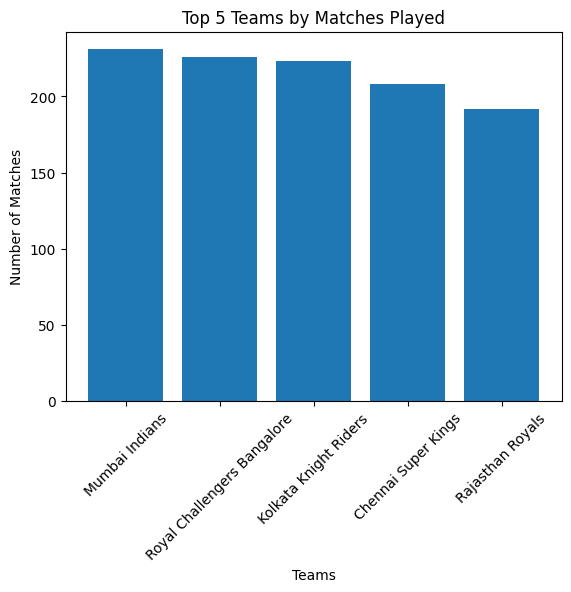

In [104]:
###`Q-6` Write a code which can display the bar chart of top 5 teams who have played maximum number of matches in the IPL.
# >  Hint: Be careful the data is divided in 2 different cols(Team 1 and Team 2)
ipl_combined_team1=ipl_matches["Team1"]
one=pd.Series(ipl_combined_team1)
ipl_combined_team2=ipl_matches["Team2"]
two=pd.Series(ipl_combined_team2)
combined=pd.concat((one,two))
top_5_teams=combined.value_counts().head(5)
plt.bar(top_5_teams.index, top_5_teams.values)
plt.title("Top 5 Teams by Matches Played")
plt.ylabel("Number of Matches")
plt.xlabel("Teams")
plt.xticks(rotation=45)
plt.show()

###`Q-7:` Player who got Most no. of player of the match award playing against Mumbai Indians.
> Just for this question assume player of the match award is given to players from winning team. Although this is true in most of the cases.


In [107]:
mi_matches = ipl_matches[(ipl_matches['Team1'] == 'Mumbai Indians') | (ipl_matches['Team2'] == 'Mumbai Indians')]
players = mi_matches['Player_of_Match']
player_counts = players.value_counts()
top_player = player_counts.head(1)
print("Player with most 'Player of the Match' awards against Mumbai Indians:", top_player)

Player with most 'Player of the Match' awards against Mumbai Indians: Player_of_Match
RG Sharma    16
Name: count, dtype: int64


###`Q-8:` Team1 vs Team2 Dashbord
Create a function which will take two string(name of two teams) as input. Show win Loss record between them and player getting most player of the match award in matches between these two teams.
```
team1_vs_team2('Kolkata Knight Riders','Chennai Super Kings')
```

In [108]:
def team1_vs_team2(team1, team2):
    # Filter matches between the two teams
    matches = ipl_matches[
        ((ipl_matches['Team1'] == team1) & (ipl_matches['Team2'] == team2)) |
        ((ipl_matches['Team1'] == team2) & (ipl_matches['Team2'] == team1))
    ]
    
    # Win-Loss record
    win_record = matches['winner'].value_counts()
    
    # Player with most Player of the Match
    top_player = matches['player_of_match'].value_counts().idxmax()
    
    print(f"Win-Loss record between {team1} and {team2}:\n{win_record}\n")
    print(f"Player with most Player of the Match awards: {top_player}")

### `Q-9:` Find out the top 7 cities where the matches of Kolkata Knight Riders are played frequently and plot the result as bar chart.

*`.plot(kind = "bar")` can help you to plot the bar chart. Also you can learn more about this method from [here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html)*



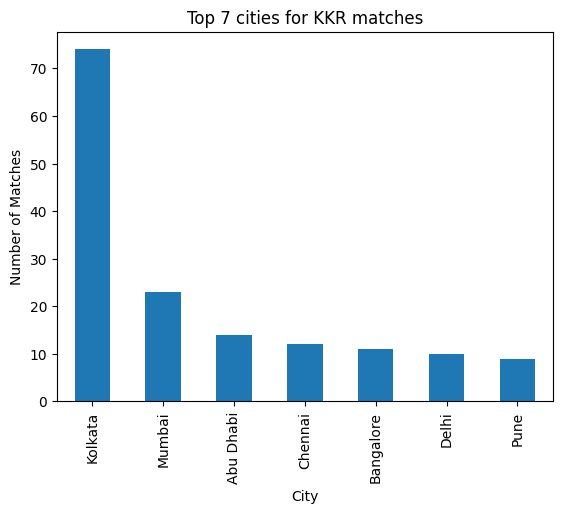

In [110]:
kkr_matches = ipl_matches[
    (ipl_matches['Team1'] == 'Kolkata Knight Riders') | 
    (ipl_matches['Team2'] == 'Kolkata Knight Riders')
]
city_counts = kkr_matches['City'].value_counts().head(7)
city_counts.plot(kind='bar', title='Top 7 cities for KKR matches')
plt.ylabel('Number of Matches')
plt.show()

### `Q-10:` Find out the average margin for the team Mumbai Indians for only the session 2011.

In [114]:
ipl_matches.columns

Index(['ID', 'City', 'Date', 'Season', 'MatchNumber', 'Team1', 'Team2',
       'Venue', 'TossWinner', 'TossDecision', 'SuperOver', 'WinningTeam',
       'WonBy', 'Margin', 'method', 'Player_of_Match', 'Team1Players',
       'Team2Players', 'Umpire1', 'Umpire2'],
      dtype='object')

In [115]:
mi_2011 = ipl_matches[
    (ipl_matches['WinningTeam'] == 'Mumbai Indians') & 
    (ipl_matches['Season'] == 2011)
]
average_margin = mi_2011['Margin'].mean()
print("Average margin for Mumbai Indians in 2011:", average_margin)
mi_2011_runs = mi_2011[mi_2011['WonBy'] == 'runs']['Margin'].mean()
mi_2011_wickets = mi_2011[mi_2011['WonBy'] == 'wickets']['Margin'].mean()

print("Average margin by runs:", mi_2011_runs)
print("Average margin by wickets:", mi_2011_wickets)

Average margin for Mumbai Indians in 2011: nan
Average margin by runs: nan
Average margin by wickets: nan
